<a href="https://colab.research.google.com/github/brainExplorer/python-data-visualization/blob/main/data_analysis_with_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><b><center> PYTHON İLE VERİ ANALİZİ </center></b></h1>

<h1>1. Ortamın Hazırlanması ve Kütüphanelerin İçe Aktarılması</h1>

Veri analizinin olmazsa olmazı, doğru kütüphaneleri içe aktarmaktır. Bu kütüphaneler, veriyi işlemekten (Pandas, NumPy) görselleştirmeye (Matplotlib, Seaborn) ve makine öğrenmesi modelleri kurmaya (Scikit-learn) kadar her aşamada kullanılır.

In [56]:
libraries = {
    # Temel kütüphaneler
    'numpy' : 'import numpy as np',
    'pandas' : 'import pandas as pd',

    # Görselleştirme kütüphaneleri
    'matplotlib' : 'import matplotlib.pyplot as plt',
    'seaborn' : 'import seaborn as sns',

    # Makine öğrenmesi kütüphaneleri
    'sklearn.model_selection' : 'from sklearn.model_selection import train_test_split',
    'sklearn.preprocessing' : 'from sklearn.preprocessing import StandardScaler',
    'sklearn.linear_model' : 'from sklearn.linear_model import LinearRegression',
    'sklearn.metrics' : 'from sklearn.metrics import mean_squared_error, r2_score',
}

for name, command in libraries.items():
    try:
        exec(command)
        print(f"{name} imported successfully.")
    except ImportError:
        print(f"Failed to import {name}.")
    except Exception as e:
        print(f"An error occurred while importing {name}: {e}")
    finally:
        print("=" * 50)

# Görsellerin notebook içinde gösterilmesi için
%matplotlib inline



numpy imported successfully.
pandas imported successfully.
matplotlib imported successfully.
seaborn imported successfully.
sklearn.model_selection imported successfully.
sklearn.preprocessing imported successfully.
sklearn.linear_model imported successfully.
sklearn.metrics imported successfully.


<h1> 2. Pandas ile Veri Manipülasyonu (Data Wrangling) </h1>
<article><b>Pandas</b> veri analizinin kalbidir. <b>DataFrame</b> ve <b>Series</b> yapılarıyla veri yüklemek, temizlemek, filtrelemek ve dönüştürmek için kullanılır.</article>

<h2>2.1. Temel DataFrame İşlemleri</h2>

In [57]:
# Örnek veri seti
# Örnek veri seti
data = {
    'Name': [
        'John', 'Jane', 'Mike', 'Emily', 'David',
        'Martin', 'Sophia', 'Daniel', 'Olivia', 'James',
        'Emma', 'William', 'Ava', 'Benjamin', 'Charlotte'
    ],

    'Age': [
        25, 30, 35, 28, 40,
        42, 27, 33, 29, 38,
        26, 45, 31, 36, 24
    ],

    'City': [
        'New York', 'London', 'Paris', 'Tokyo', 'Sydney',
        'Tokyo', 'Berlin', 'Toronto', 'New York', 'London',
        'Paris', 'Sydney', 'Berlin', 'Toronto', 'Tokyo'
    ],

    'Salary': [
        50000, 60000, 70000, 55000, 80000,
        72000, 58000, 68000, 62000, 76000,
        54000, 90000, 65000, 73000, 52000
    ]
}


df = pd.DataFrame(data)

print(f"Oluşturulan DataFrame:\n{df}")


Oluşturulan DataFrame:
         Name  Age      City  Salary
0        John   25  New York   50000
1        Jane   30    London   60000
2        Mike   35     Paris   70000
3       Emily   28     Tokyo   55000
4       David   40    Sydney   80000
5      Martin   42     Tokyo   72000
6      Sophia   27    Berlin   58000
7      Daniel   33   Toronto   68000
8      Olivia   29  New York   62000
9       James   38    London   76000
10       Emma   26     Paris   54000
11    William   45    Sydney   90000
12        Ava   31    Berlin   65000
13   Benjamin   36   Toronto   73000
14  Charlotte   24     Tokyo   52000


<h2>Pratik Soru 1: <code inline>df</code> içerisinden sadece 'Name' ve 'Salary' sütunlarını seçen kodu yazın.</h2>
<details> <summary>💡 İpucu</summary> Birden fazla sütunu seçmek için çift köşeli parantez kullanılır: `df[['sütun1', 'sütun2']]` </details>

In [58]:
df[["Name","Salary"]]

,Name,Salary
0,John,50000
1,Jane,60000
2,Mike,70000
3,Emily,55000
4,David,80000
5,Martin,72000
6,Sophia,58000
7,Daniel,68000
8,Olivia,62000
9,James,76000


<h2>2.2. Veriyi Filtreleme ve Koşullu Seçim</h2>

In [59]:
# Select the salary greater than 5500
high_salary = df[df['Salary'] > 55000]

print(f"Maaş 55000'den yüksek olanlar:\n{high_salary}")

Maaş 55000'den yüksek olanlar:
        Name  Age      City  Salary
1       Jane   30    London   60000
2       Mike   35     Paris   70000
4      David   40    Sydney   80000
5     Martin   42     Tokyo   72000
6     Sophia   27    Berlin   58000
7     Daniel   33   Toronto   68000
8     Olivia   29  New York   62000
9      James   38    London   76000
11   William   45    Sydney   90000
12       Ava   31    Berlin   65000
13  Benjamin   36   Toronto   73000


<h2>Pratik Soru 2: Yaşı 30'dan büyük ve Tokyo'da yaşayan kişileri listeleyin.</h2>
<details> <summary>💡 İpucu</summary> Koşulları `&` (ve) operatörü ile birleştirin ve her koşulu parantez içine alın: `(df['Yas'] > 30) & (df['Sehir'] == 'Tokyo')` </details>

In [60]:
ac = (df['Age']>30) & (df['City'] == 'Tokyo')
print(f"Yaşı 30'dan büyük ve Tokyo'da yaşayanlar:\n{df[ac]}")


Yaşı 30'dan büyük ve Tokyo'da yaşayanlar:
     Name  Age   City  Salary
5  Martin   42  Tokyo   72000


<h2>2.3. Gruplama ve Özet İstatistikler</h2>

In [61]:
# Şehirlere göre ortalama maaş
avg_city = df.groupby('City')['Salary'].mean().reset_index().rename(columns={'Salary': 'Average Salary'})
print(f'Şehirlere göre ortalama maaş:\n\n{avg_city}')

Şehirlere göre ortalama maaş:

       City  Average Salary
0    Berlin    61500.000000
1    London    68000.000000
2  New York    56000.000000
3     Paris    62000.000000
4    Sydney    85000.000000
5     Tokyo    59666.666667
6   Toronto    70500.000000


<h2>Pratik Soru 3: <code>groupby</code> kullanarak her şehirdeki kişi sayısını (count) bulun.</h2>
<details> <summary>💡 İpucu</summary> `groupby` sonrası `count()` veya `size()` metodunu kullanabilirsiniz. </details>

In [62]:
cnt_populations = df.groupby('City')['Name'].count()
cnt_populations

,Name
City,
Berlin,2
London,2
New York,2
Paris,2
Sydney,2
Tokyo,3
Toronto,2


<h2>2.4. Eksik Verilerle Başa Çıkma</h2>

In [63]:
# Eksik veri içeren bir DataFrame oluşturalım
df_eksik = pd.DataFrame({
    'A': [1, 2, np.nan, 4],
    'B': [5, np.nan, np.nan, 8],
    'C': [9, 10, 11, 12]
})

print(f"Eksik Veri İçeren DataFrame:\n{df_eksik}")


# Eksik verileri kontrol etme
print(f"\nEksik Veri Kontrolü:\n{df_eksik.isnull()}")

# Eksik verilerin toplamı
print(f"\nEksik Verilerin Toplamı:\n{df_eksik.isnull().sum()}")

# Eksik verileri doldurma
df_eksik.fillna(df_eksik.mean())

print(f"\nOrtalama ile doldurulmuş DataFrame:\n{df_eksik}")


Eksik Veri İçeren DataFrame:
     A    B   C
0  1.0  5.0   9
1  2.0  NaN  10
2  NaN  NaN  11
3  4.0  8.0  12

Eksik Veri Kontrolü:
       A      B      C
0  False  False  False
1  False   True  False
2   True   True  False
3  False  False  False

Eksik Verilerin Toplamı:
A    1
B    2
C    0
dtype: int64

Ortalama ile doldurulmuş DataFrame:
     A    B   C
0  1.0  5.0   9
1  2.0  NaN  10
2  NaN  NaN  11
3  4.0  8.0  12


<h2>Pratik Soru 4: Eksik verileri sütunun medyan değeri ile doldurun.</h2>
<details> <summary>💡 İpucu</summary> `fillna` metoduna `df_eksik.median()` parametresini geçin. </details>

In [64]:
# Orijinal DataFrame değişmesin istiyorsanız inplace=False yapabilirsiniz veya boş
#bıraksanız da varsayılan olarak aynı özelliği gösterecektir.
df_eksik.fillna(df_eksik.median(), inplace=True)
df_eksik

,A,B,C
0,1.0,5.0,9
1,2.0,6.5,10
2,2.0,6.5,11
3,4.0,8.0,12


<h1>3. NumPy ile Sayısal İşlemler</h1>

<article>NumPy, büyük ve çok boyutlu diziler (array) üzerinde hızlı matematiksel işlemler yapmak için kullanılır</article>

In [65]:
# Numpy dizisi oluşturma
arr = np.array([1, 2, 3, 4, 5])

print(f"Oluşturulan NumPy Dizisi: {arr}")


# Temel istatistikler
print(f"\nOrtalama: {np.mean(arr)}")
print(f"Medyan: {np.median(arr)}")
print(f"Standart Sapma: {np.std(arr)}")


# Vektörel işlemler
arr2 = np.array([6, 7, 8, 9, 10])
print(f"\nToplama: {arr + arr2}")
print(f"Çıkarma: {arr - arr2}")

Oluşturulan NumPy Dizisi: [1 2 3 4 5]

Ortalama: 3.0
Medyan: 3.0
Standart Sapma: 1.4142135623730951

Toplama: [ 7  9 11 13 15]
Çıkarma: [-5 -5 -5 -5 -5]


<h2>Pratik Soru 5: 0 ile 100 arasında 20 eşit aralıklı sayıdan oluşan bir NumPy dizisi oluşturun.<h2>
<details> <summary>💡 İpucu</summary> `np.linspace(0, 100, 20)` fonksiyonunu kullanın. </details>

In [66]:
p_arr = np.linspace(0,100,20)
p_arr

array([  0.        ,   5.26315789,  10.52631579,  15.78947368,
        21.05263158,  26.31578947,  31.57894737,  36.84210526,
        42.10526316,  47.36842105,  52.63157895,  57.89473684,
        63.15789474,  68.42105263,  73.68421053,  78.94736842,
        84.21052632,  89.47368421,  94.73684211, 100.        ])

<h1>4. Veri Görselleştirme (Data Visualization)</h1>
Veriyi anlamanın ve başkalarına sunmanın en etkili yolu görselleştirmedir.
<h2>4.1. Matplotlib ile Temel Grafikler</h2>

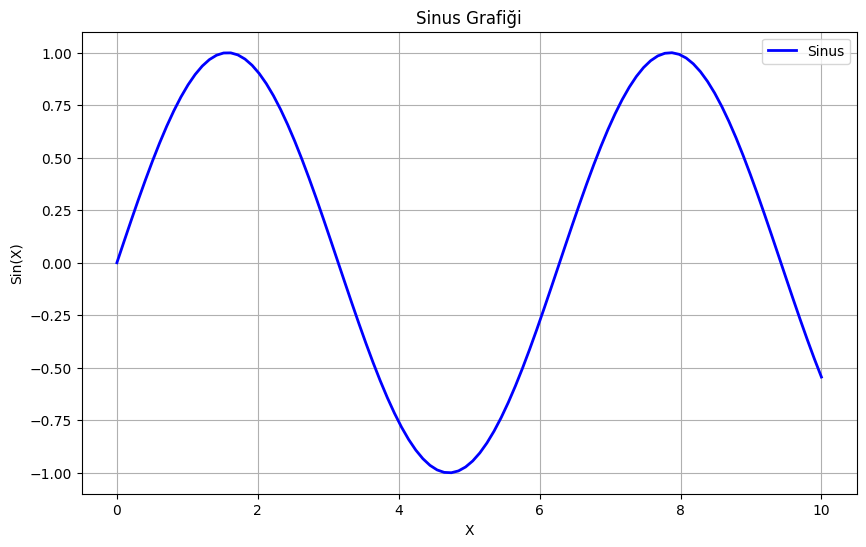

In [67]:
# Basit bir çizgi grafiği
x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Sinus', color='blue', linewidth=2)
plt.xlabel('X')
plt.ylabel('Sin(X)')
plt.title('Sinus Grafiği')
plt.legend()
plt.grid(True)
plt.show()

<h2>4.2. Seaborn ile İstatistiksel Grafikler</h2>

Seaborn, Matplotlib'e göre daha gelişmiş ve estetik görselleştirmeler sunar

Tips Veri Seti İlk 5 Satır:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


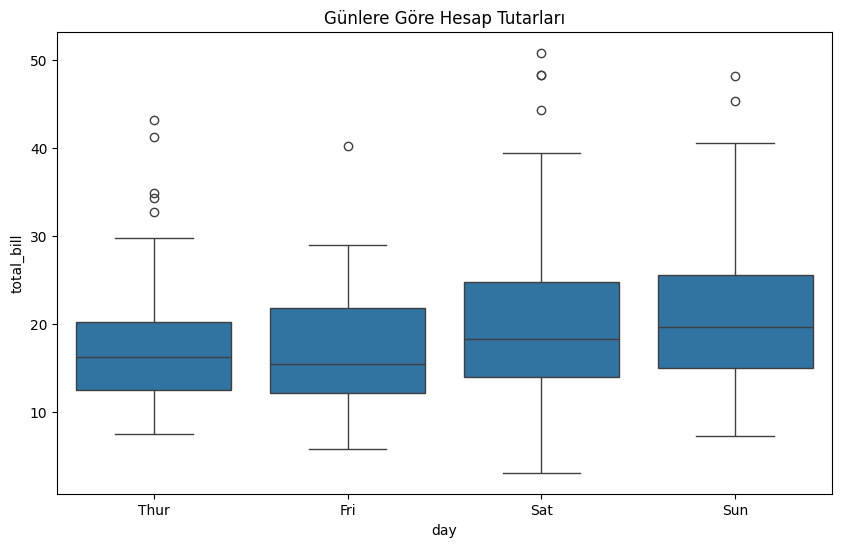

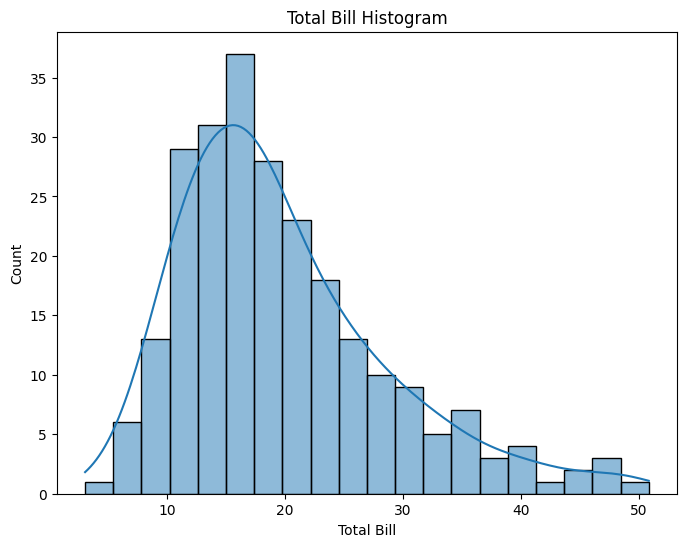

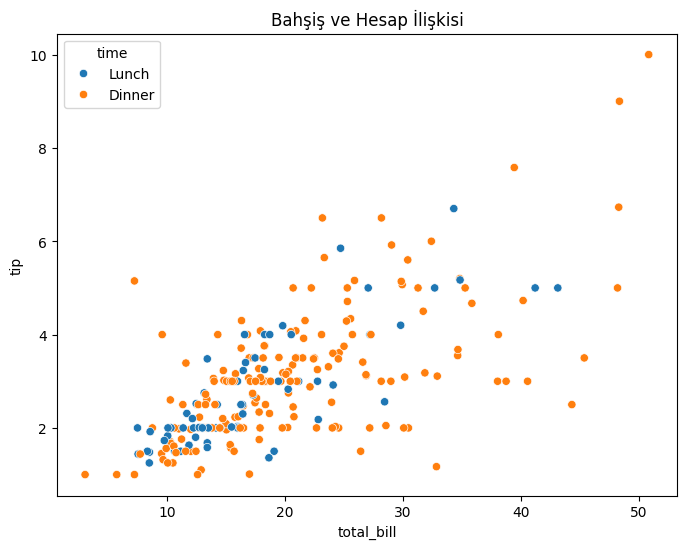

/tmp/ipykernel_6794/2489453752.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_avg = tips.groupby('day')['total_bill'].mean().reset_index()


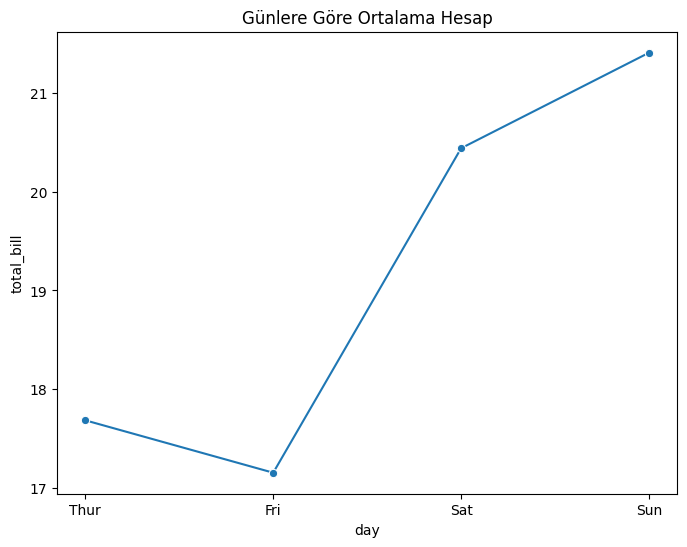

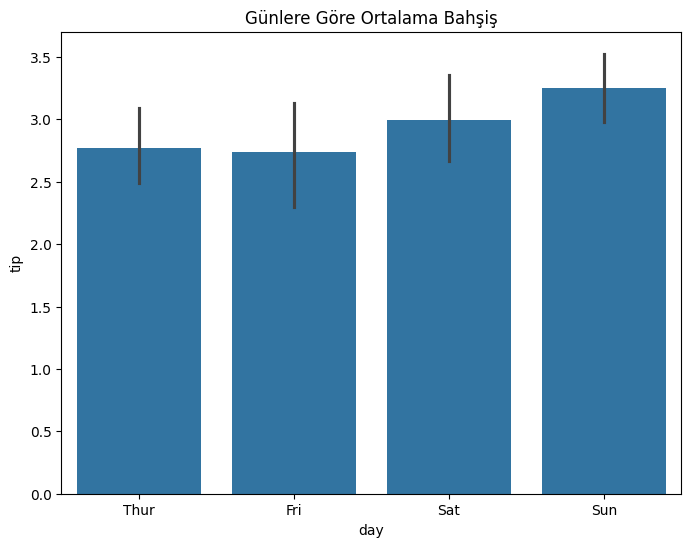

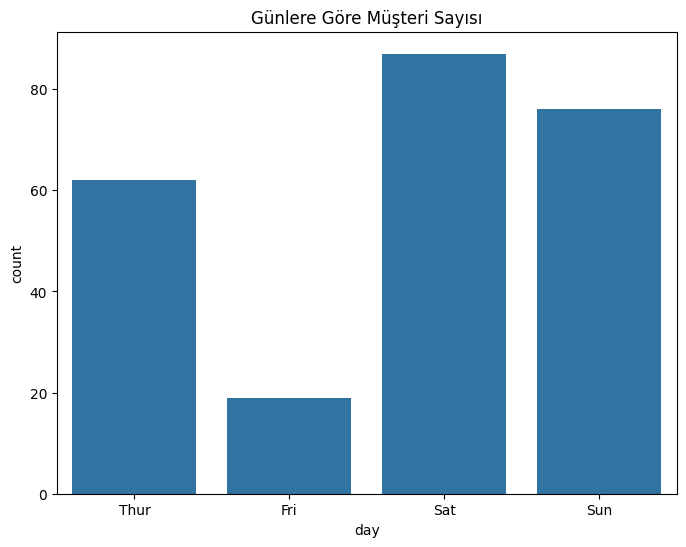

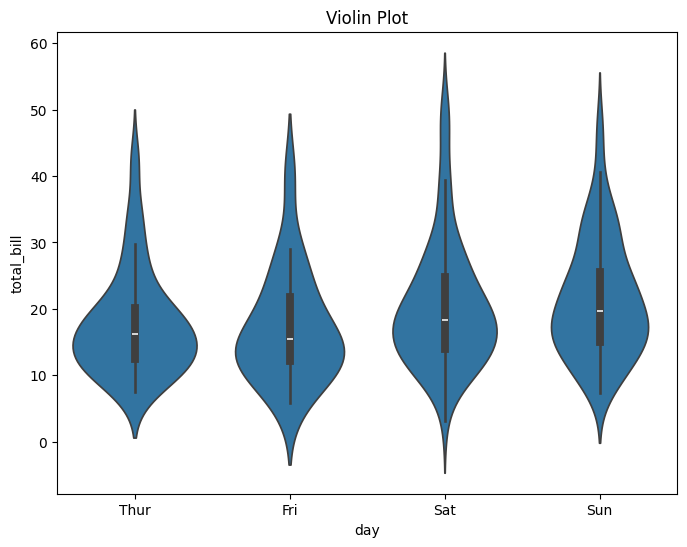

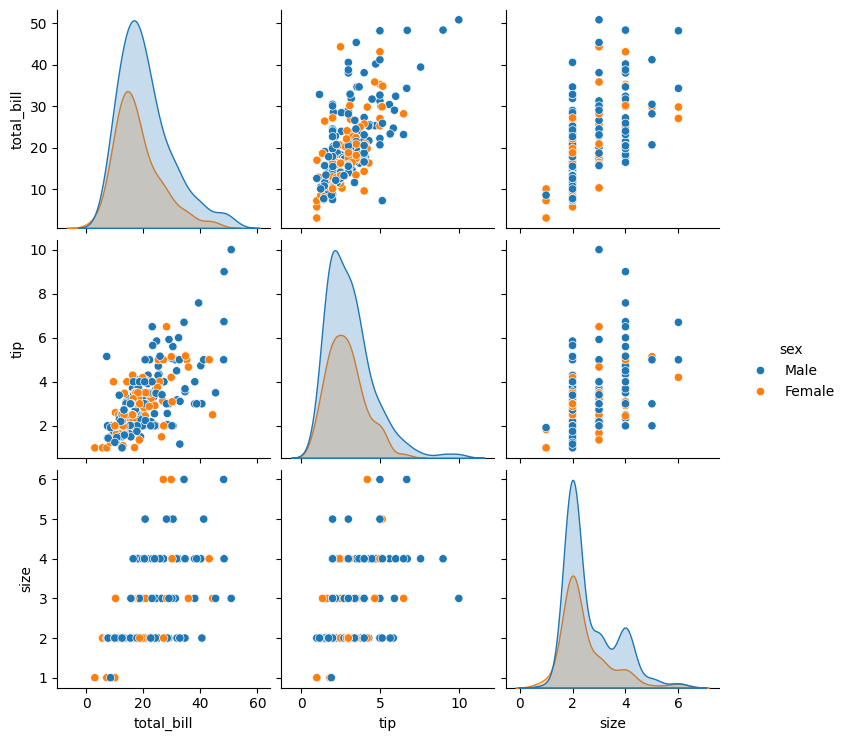

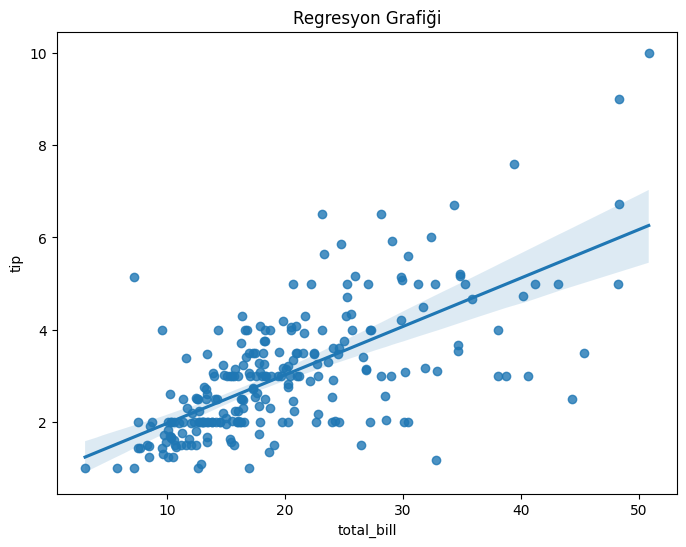

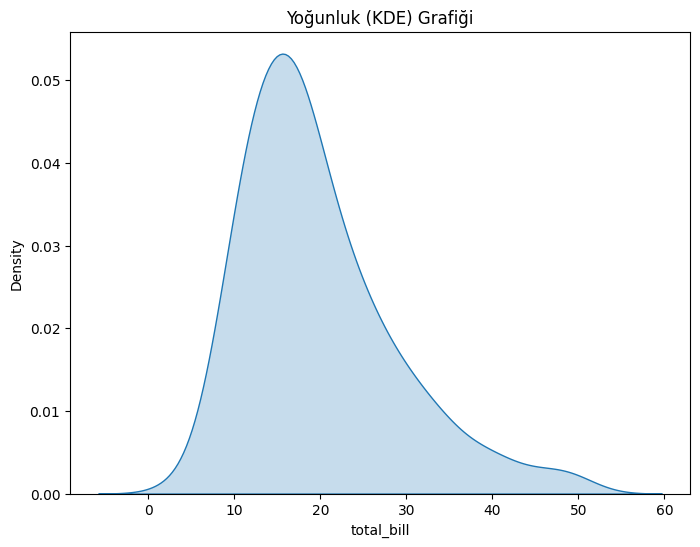

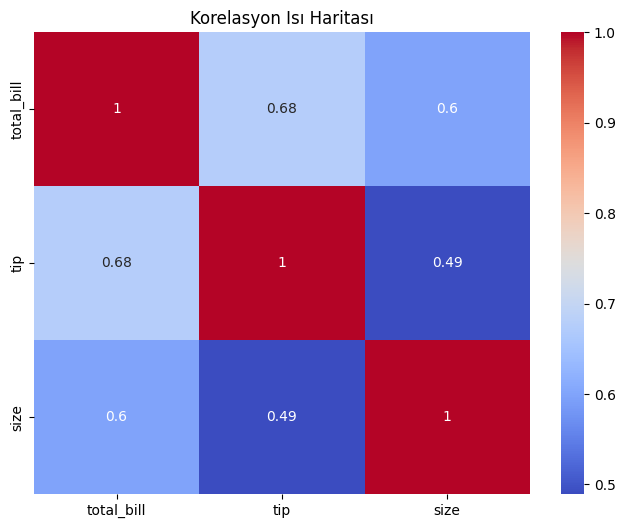

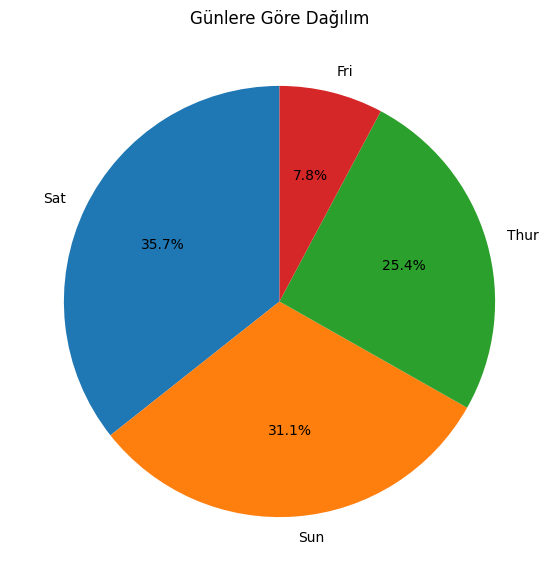

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

# Örnek veri seti
tips = sns.load_dataset('tips')

print("Tips Veri Seti İlk 5 Satır:")
print(tips.head())

####################################################
# 1. Box Plot
####################################################
plt.figure(figsize=(10,6))
sns.boxplot(x='day', y='total_bill', data=tips)
plt.title('Günlere Göre Hesap Tutarları')
plt.show()

####################################################
# 2. Histogram
####################################################
plt.figure(figsize=(8,6))
sns.histplot(tips['total_bill'], bins=20, kde=True)
plt.title("Total Bill Histogram")
plt.xlabel("Total Bill")
plt.show()

####################################################
# 3. Scatter Plot
####################################################
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='total_bill',
    y='tip',
    hue='time',
    data=tips
)
plt.title("Bahşiş ve Hesap İlişkisi")
plt.show()

####################################################
# 4. Line Plot
####################################################
daily_avg = tips.groupby('day')['total_bill'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.lineplot(
    x='day',
    y='total_bill',
    data=daily_avg,
    marker='o'
)
plt.title("Günlere Göre Ortalama Hesap")
plt.show()

####################################################
# 5. Bar Plot
####################################################
plt.figure(figsize=(8,6))
sns.barplot(
    x='day',
    y='tip',
    data=tips,
    estimator='mean'
)
plt.title("Günlere Göre Ortalama Bahşiş")
plt.show()

####################################################
# 6. Count Plot
####################################################
plt.figure(figsize=(8,6))
sns.countplot(
    x='day',
    data=tips
)
plt.title("Günlere Göre Müşteri Sayısı")
plt.show()

####################################################
# 7. Violin Plot
####################################################
plt.figure(figsize=(8,6))
sns.violinplot(
    x='day',
    y='total_bill',
    data=tips
)
plt.title("Violin Plot")
plt.show()

####################################################
# 8. Pair Plot
####################################################
sns.pairplot(
    tips,
    hue='sex'
)
plt.show()

####################################################
# 9. Regression Plot
####################################################
plt.figure(figsize=(8,6))
sns.regplot(
    x='total_bill',
    y='tip',
    data=tips
)
plt.title("Regresyon Grafiği")
plt.show()

####################################################
# 10. KDE Plot
####################################################
plt.figure(figsize=(8,6))
sns.kdeplot(
    data=tips,
    x='total_bill',
    fill=True
)
plt.title("Yoğunluk (KDE) Grafiği")
plt.show()

####################################################
# 11. Heatmap (Korelasyon)
####################################################
plt.figure(figsize=(8,6))
sns.heatmap(
    tips.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title("Korelasyon Isı Haritası")
plt.show()

####################################################
# 12. Pie Chart
####################################################
day_counts = tips['day'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    day_counts,
    labels=day_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Günlere Göre Dağılım")
plt.show()

<h2>Pratik Soru 6: tips veri setinde cinsiyete (sex) göre hesap tutarlarının (total_bill) dağılımını gösteren bir violin plot çizin.</h2>
<details> <summary>💡 İpucu</summary> `sns.violinplot(x='sex', y='total_bill', data=tips)` kodunu kullanabilirsiniz. </details>

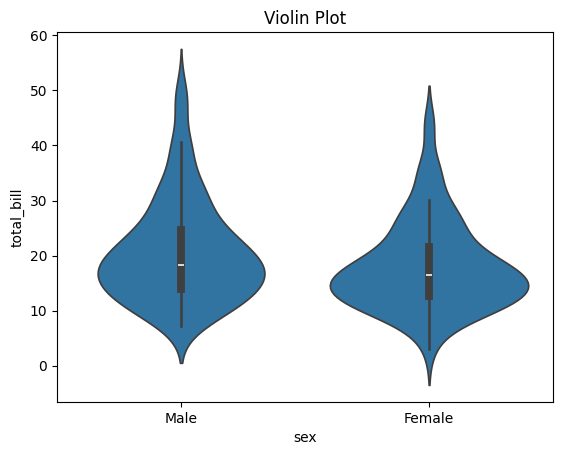

In [69]:
sns.violinplot(x='sex', y='total_bill', data=tips)
plt.title("Violin Plot")
plt.show()

<h2>5. Keşfedici Veri Analizi (EDA - Exploratory Data Analysis)
</h2>
EDA, veriyi anlamak, gizli kalmış ilişkileri keşfetmek ve modelleme öncesi hipotezler oluşturmak için yapılan analizlerin tamamıdır.

In [70]:
print(f"Tips veriseti bilgisi: {tips.info()}")

print(f"\nBetimsel istatistikler: {tips.describe()}")

# kategorik değişkenerin dağılımı
print(f"\nKategorik değişken dağılımı: {tips['day'].value_counts()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
Tips veriseti bilgisi: None

Betimsel istatistikler:        total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000

Kategorik değişken dağı

<h1>6. Scikit-learn ile Makine Öğrenmesi: Lineer Regresyon</h1>

Scikit-learn, Python'daki en popüler makine öğrenmesi kütüphanesidir. Basit bir lineer regresyon modeli kuralım.

In [71]:
# Basit bir veri seti oluşturalım
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3*X + np.random.randn(100, 1)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model oluşturma ve eğitme
model = LinearRegression()
model.fit(X_train, y_train)

# Tahminler
y_pred = model.predict(X_test)

# Model performansını değerlendirme
print(f"Eğitim Seti R^2: {model.score(X_train, y_train)}")
print(f"Test Seti R^2: {model.score(X_test, y_test)}")
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"Model katsayısı (slope): {model.coef_[0][0]}")
print(f"Model sabiti (intercept): {model.intercept_[0]}")



Eğitim Seti R^2: 0.7582381034538057
Test Seti R^2: 0.8072059636181392
MSE: 0.6536995137170021
RMSE: 0.8085168605026132
Model katsayısı (slope): 2.7993236574802762
Model sabiti (intercept): 4.142913319458566


<h2>Pratik Soru 7: Yukarıdaki modelde test seti büyüklüğünü 0.3 olarak değiştirip, R² skorlarındaki değişimi gözlemleyin.</h2>
<details> <summary>💡 İpucu</summary> `train_test_split` fonksiyonundaki `test_size` parametresini `0.3` olarak güncelleyin. </details>

In [72]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Eğitim Seti R^2: {model.score(X_train, y_train)}")
print(f"Test Seti R^2: {model.score(X_test, y_test)}")

Eğitim Seti R^2: 0.7238333932891039
Test Seti R^2: 0.8495602326572158


<h1>7. BONUS: Gerçek Hayat Senaryosu ile Pratik
</h1>
Şimdi öğrendiklerini tek bir senaryoda birleştirelim.

Senaryo: Bir şirketin müşteri memnuniyeti verilerini analiz ediyorsun. Veri setinde müşteri yaşı, geliri, harcama puanı ve memnuniyet puanı var. Amacın, memnuniyet puanını etkileyen faktörleri bulmak ve basit bir model kurmak.

             Yas         Gelir  Harcama_Puani  Memnuniyet
count  200.00000     200.00000     200.000000  200.000000
mean    43.42500   68912.25500      49.670000    4.815000
std     14.94191   29382.16432      29.370636    2.593144
min     18.00000   20301.00000       1.000000    1.000000
25%     31.00000   43269.25000      24.000000    3.000000
50%     43.50000   68379.00000      50.000000    5.000000
75%     56.00000   92768.25000      73.250000    7.000000
max     69.00000  119522.00000      99.000000    9.000000
                    Yas     Gelir  Harcama_Puani  Memnuniyet
Yas            1.000000 -0.023611       0.082319   -0.087708
Gelir         -0.023611  1.000000      -0.127189   -0.020487
Harcama_Puani  0.082319 -0.127189       1.000000    0.044126
Memnuniyet    -0.087708 -0.020487       0.044126    1.000000


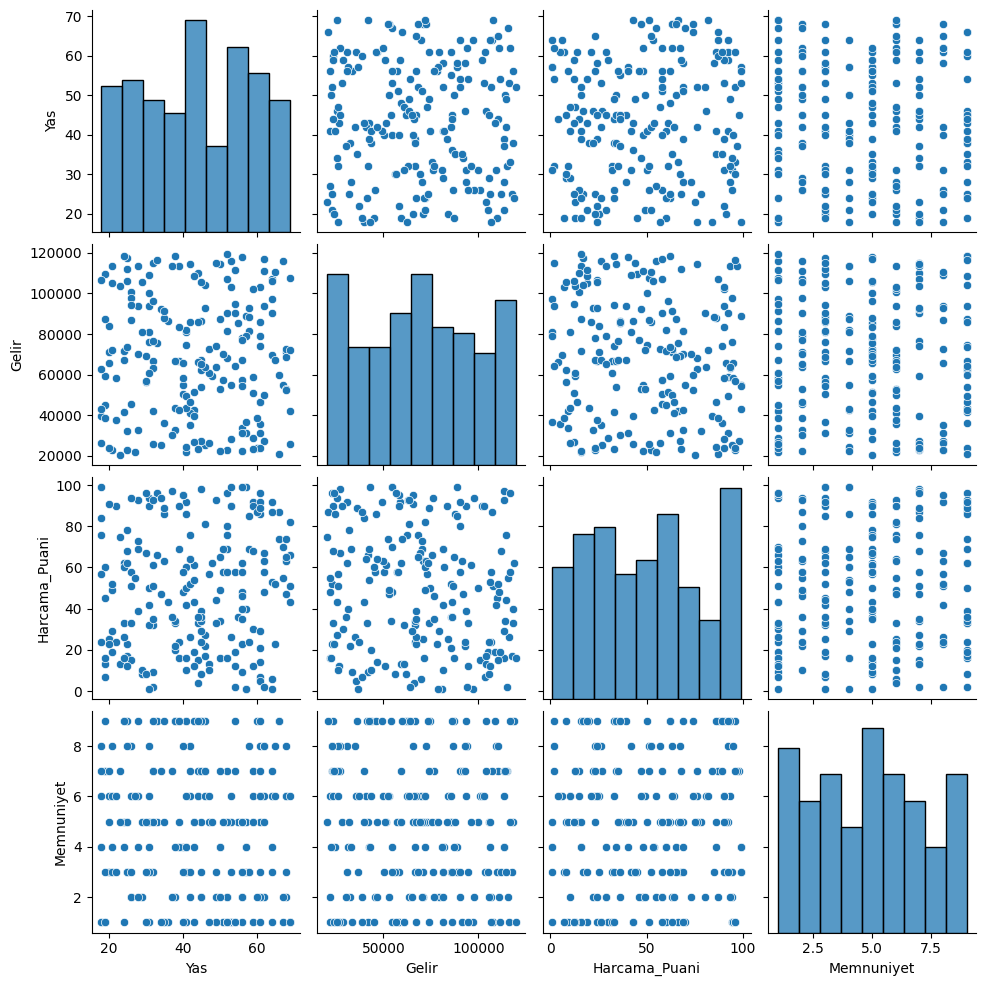

Model R² Skoru: -0.060006476319445445


In [73]:
# Veri setini oluşturalım
np.random.seed(42)
musteri_sayisi = 200
veri = {
    'Yas': np.random.randint(18, 70, musteri_sayisi),
    'Gelir': np.random.randint(20000, 120000, musteri_sayisi),
    'Harcama_Puani': np.random.randint(1, 100, musteri_sayisi),
    'Memnuniyet': np.random.randint(1, 10, musteri_sayisi)
}
df_musteri = pd.DataFrame(veri)
df_musteri.head()

# 1. Veriyi Keşfedin (EDA)
print(df_musteri.describe())
print(df_musteri.corr(numeric_only=True))

# 2. Görselleştirme
sns.pairplot(df_musteri)
plt.show()

# 3. Basit bir lineer regresyon modeli kurun (Memnuniyet ~ Gelir + Harcama_Puani)
X = df_musteri[['Gelir', 'Harcama_Puani']]
y = df_musteri['Memnuniyet']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_musteri = LinearRegression()
model_musteri.fit(X_train, y_train)
print("Model R² Skoru:", model_musteri.score(X_test, y_test))